# HOSPIQ — Exploratory Data Analysis
## Hero DMC Heart Institute — HDHI Admission Dataset
### Phase 1 of 7: Understanding the data before touching infrastructure

**Why EDA comes first:**
A data analyst never builds pipelines on data they do not understand.
This notebook explores the raw dataset to identify quality issues,
understand distributions, and document every cleaning decision
before a single transformation is applied.

**Dataset:** 2 years of real cardiac admissions from Hero DMC
Heart Institute, Ludhiana, Punjab, India (Apr 2017 – Mar 2019)

## 2. Data Loading
Loading the raw CSV and inspecting its basic structure.
No transformations applied here — this is the data as received.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load raw data
df = pd.read_csv('data/raw/HDHI Admission data.csv')

# Basic structure
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

# Column names
print("\nAll columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

# First 5 rows
df.head()

Shape: (15757, 56)
Rows: 15,757
Columns: 56
Memory usage: 18410.3 KB

All columns:
   1. SNO
   2. MRD No.
   3. D.O.A
   4. D.O.D
   5. AGE
   6. GENDER
   7. RURAL
   8. TYPE OF ADMISSION-EMERGENCY/OPD
   9. month year
  10. DURATION OF STAY
  11. duration of intensive unit stay
  12. OUTCOME
  13. SMOKING 
  14. ALCOHOL
  15. DM
  16. HTN
  17. CAD
  18. PRIOR CMP
  19. CKD
  20. HB
  21. TLC
  22. PLATELETS
  23. GLUCOSE
  24. UREA
  25. CREATININE
  26. BNP
  27. RAISED CARDIAC ENZYMES
  28. EF
  29. SEVERE ANAEMIA
  30. ANAEMIA
  31. STABLE ANGINA
  32. ACS
  33. STEMI
  34. ATYPICAL CHEST PAIN
  35. HEART FAILURE
  36. HFREF
  37. HFNEF
  38. VALVULAR
  39. CHB
  40. SSS
  41. AKI
  42. CVA INFRACT
  43. CVA BLEED
  44. AF
  45. VT
  46. PSVT
  47. CONGENITAL
  48. UTI
  49. NEURO CARDIOGENIC SYNCOPE
  50. ORTHOSTATIC
  51. INFECTIVE ENDOCARDITIS
  52. DVT
  53. CARDIOGENIC SHOCK
  54. SHOCK
  55. PULMONARY EMBOLISM
  56. CHEST INFECTION


,SNO,MRD No.,D.O.A,D.O.D,AGE,GENDER,RURAL,TYPE OF ADMISSION-EMERGENCY/OPD,month year,DURATION OF STAY,...,CONGENITAL,UTI,NEURO CARDIOGENIC SYNCOPE,ORTHOSTATIC,INFECTIVE ENDOCARDITIS,DVT,CARDIOGENIC SHOCK,SHOCK,PULMONARY EMBOLISM,CHEST INFECTION
0,1,234735,4/1/2017,4/3/2017,81,M,R,E,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0
1,2,234696,4/1/2017,4/5/2017,65,M,R,E,Apr-17,5,...,0,0,0,0,0,0,0,0,0,0
2,3,234882,4/1/2017,4/3/2017,53,M,U,E,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0
3,4,234635,4/1/2017,4/8/2017,67,F,U,E,Apr-17,8,...,0,0,0,0,0,0,0,0,0,0
4,5,234486,4/1/2017,4/23/2017,60,F,U,E,Apr-17,23,...,0,0,0,0,0,0,0,0,0,0


## 3. Null Analysis
Identifying missing values is the most critical first step.
High missing rates change how we can use a variable.
Columns with over 20% missing require special handling decisions.

Columns with missing values (sorted by % missing):
            null_count  null_pct
BNP               8441     53.57
EF                1505      9.55
GLUCOSE            863      5.48
TLC                286      1.82
PLATELETS          285      1.81
HB                 252      1.60
CREATININE         247      1.57
UREA               241      1.53

⚠️  CRITICAL: Columns with over 20% missing:
  BNP: 8,441 missing (53.57%)


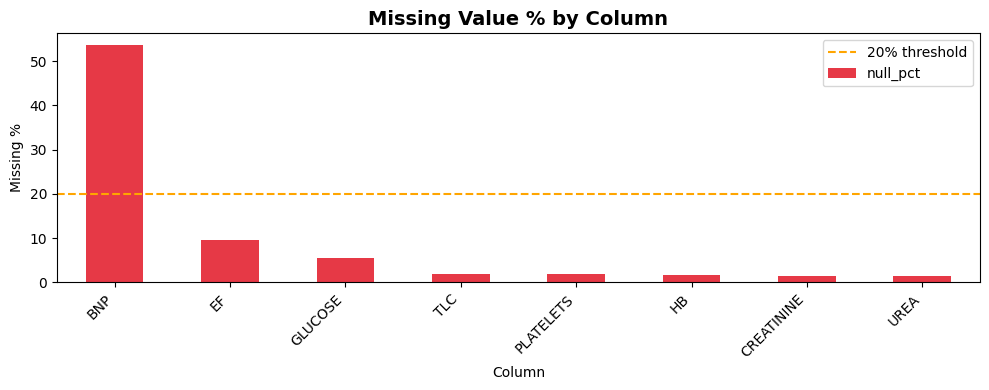

Chart saved: eda_01_null_analysis.png


In [2]:
# Null count and percentage
null_df = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('null_pct', ascending=False)

null_df = null_df[null_df['null_count'] > 0]
print("Columns with missing values (sorted by % missing):")
print(null_df.to_string())

# Flag critical missing
print("\n⚠️  CRITICAL: Columns with over 20% missing:")
critical = null_df[null_df['null_pct'] > 20]
for col, row in critical.iterrows():
    print(f"  {col}: {row['null_count']:,.0f} missing ({row['null_pct']}%)")

# Visualise nulls
fig, ax = plt.subplots(figsize=(10, 4))
null_df[null_df['null_count'] > 0]['null_pct'].plot(
    kind='bar', color='#E63946', ax=ax)
ax.set_title('Missing Value % by Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
ax.axhline(y=20, color='orange', linestyle='--', label='20% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('assets/screenshots/eda_01_null_analysis.png', dpi=150)
plt.show()
print("Chart saved: eda_01_null_analysis.png")

## 4. Duplicate Analysis
Checking for duplicate records and repeat patient admissions.
This is critical because duplicates and repeat visits are
treated differently — true duplicates should be removed,
but a patient admitted twice is two valid records.

In [3]:
# True duplicate rows
true_dupes = df.duplicated().sum()
print(f"True duplicate rows (all columns identical): {true_dupes}")

# Repeat admissions by MRD No.
mrd_counts = df['MRD No.'].value_counts()
unique_patients = mrd_counts.shape[0]
repeat_admissions = (mrd_counts > 1).sum()
total_repeat_records = mrd_counts[mrd_counts > 1].sum() - repeat_admissions

print(f"\nTotal rows: {len(df):,}")
print(f"Unique patients (MRD No.): {unique_patients:,}")
print(f"Patients with multiple admissions: {repeat_admissions:,}")
print(f"Extra admission records from repeats: {total_repeat_records:,}")
print(f"Average admissions per patient: {len(df)/unique_patients:.2f}")

# Distribution of admission frequency
print("\nAdmission frequency distribution:")
freq_dist = mrd_counts.value_counts().sort_index().head(10)
for admissions, patients in freq_dist.items():
    print(f"  {admissions} admission(s): {patients:,} patients")

# Most frequent patient
max_admissions = mrd_counts.max()
print(f"\nMost admissions by one patient: {max_admissions}")

True duplicate rows (all columns identical): 0

Total rows: 15,757
Unique patients (MRD No.): 12,244
Patients with multiple admissions: 2,598
Extra admission records from repeats: 3,513
Average admissions per patient: 1.29

Admission frequency distribution:
  1 admission(s): 9,646 patients
  2 admission(s): 2,032 patients
  3 admission(s): 376 patients
  4 admission(s): 118 patients
  5 admission(s): 41 patients
  6 admission(s): 13 patients
  7 admission(s): 6 patients
  8 admission(s): 4 patients
  9 admission(s): 4 patients
  11 admission(s): 2 patients

Most admissions by one patient: 17


## 5. Outcome Distribution
The target variable for this project.
Understanding outcome imbalance is essential before any analysis.

Patient Outcomes:
  DISCHARGE: 13,756 (87.3%)
  EXPIRY: 1,105 (7.01%)
  DAMA: 896 (5.69%)


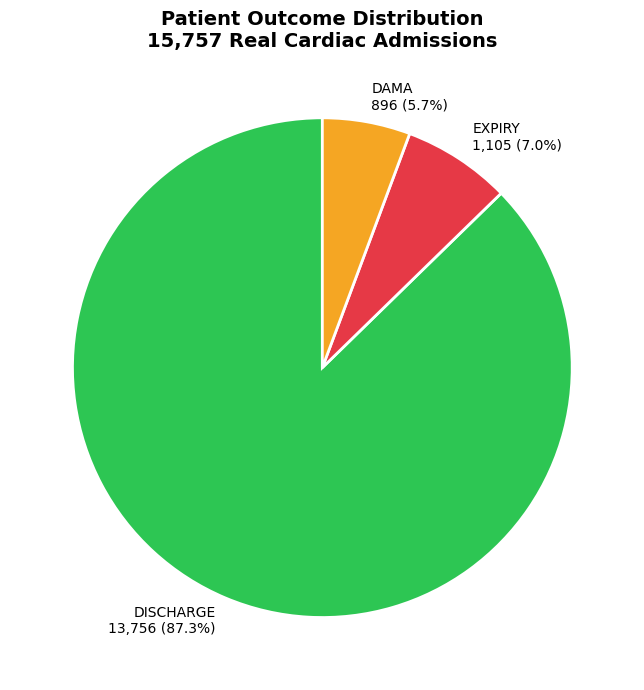

Chart saved: eda_02_outcome_distribution.png


In [4]:
# Outcome value counts
outcome_counts = df['OUTCOME'].value_counts()
outcome_pct = (df['OUTCOME'].value_counts(normalize=True) * 100).round(2)

print("Patient Outcomes:")
for outcome, count in outcome_counts.items():
    pct = outcome_pct[outcome]
    print(f"  {outcome}: {count:,} ({pct}%)")

# Visualise
fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#2DC653', '#E63946', '#F5A623']
wedges, texts, autotexts = ax.pie(
    outcome_counts.values,
    labels=[f"{o}\n{c:,} ({p:.1f}%)"
            for o, c, p in zip(outcome_counts.index,
                               outcome_counts.values,
                               outcome_pct.values)],
    colors=colors,
    autopct='',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
ax.set_title('Patient Outcome Distribution\n15,757 Real Cardiac Admissions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/screenshots/eda_02_outcome_distribution.png', dpi=150)
plt.show()
print("Chart saved: eda_02_outcome_distribution.png")

## 6. Categorical Column Analysis
Understanding the composition of the patient population.

In [5]:
# Key categorical distributions
cats = {
    'RURAL': 'Locality (Rural/Urban)',
    'TYPE OF ADMISSION-EMERGENCY/OPD': 'Admission Type',
    'GENDER': 'Gender'
}

for col, label in cats.items():
    counts = df[col].value_counts()
    pcts = (df[col].value_counts(normalize=True) * 100).round(1)
    print(f"\n{label}:")
    for val, count in counts.items():
        print(f"  {val}: {count:,} ({pcts[val]}%)")

# Comorbidity prevalence
print("\nComorbidity Prevalence:")
comorbidities = {
    'HTN': 'Hypertension',
    'DM': 'Diabetes',
    'CAD': 'Coronary Artery Disease',
    'CKD': 'Chronic Kidney Disease',
    'PRIOR CMP': 'Prior Cardiomyopathy',
    'SMOKING ': 'Smoking',
    'ALCOHOL': 'Alcohol Use'
}

for col, label in comorbidities.items():
    if col in df.columns:
        count = df[col].sum()
        pct = count / len(df) * 100
        print(f"  {label}: {int(count):,} ({pct:.1f}%)")

# Cardiac conditions
print("\nCardiac Conditions:")
conditions = {
    'HEART FAILURE': 'Heart Failure',
    'STEMI': 'STEMI',
    'CARDIOGENIC SHOCK': 'Cardiogenic Shock',
    'PULMONARY EMBOLISM': 'Pulmonary Embolism'
}

for col, label in conditions.items():
    if col in df.columns:
        count = df[col].sum()
        pct = count / len(df) * 100
        print(f"  {label}: {int(count):,} ({pct:.1f}%)")


Locality (Rural/Urban):
  U: 12,077 (76.6%)
  R: 3,680 (23.4%)

Admission Type:
  E: 10,924 (69.3%)
  O: 4,833 (30.7%)

Gender:
  M: 9,990 (63.4%)
  F: 5,767 (36.6%)

Comorbidity Prevalence:
  Hypertension: 7,656 (48.6%)
  Diabetes: 5,097 (32.3%)
  Coronary Artery Disease: 10,551 (67.0%)
  Chronic Kidney Disease: 1,550 (9.8%)
  Prior Cardiomyopathy: 2,434 (15.4%)
  Smoking: 793 (5.0%)
  Alcohol Use: 1,021 (6.5%)

Cardiac Conditions:
  Heart Failure: 4,561 (28.9%)
  STEMI: 2,202 (14.0%)
  Cardiogenic Shock: 944 (6.0%)
  Pulmonary Embolism: 242 (1.5%)


## 7. Numeric Column Analysis and Outlier Detection
Checking ranges, distributions, and extreme values for
all numeric clinical variables.

Numeric Column Summary:
Column                         Min      Max     Mean   Median    Nulls
----------------------------------------------------------------------
AGE                            4.0    110.0     61.4     62.0        0
DURATION OF STAY               1.0     98.0      6.4      5.0        0
EF                            14.0     60.0     43.5     42.0     1599
CREATININE                     0.1     15.6      1.3      1.0      251
GLUCOSE                        1.2    888.0    162.9    136.0      945
HB                             3.0     26.5     12.2     12.4      256

⚠️  Outlier Flags:
  AGE < 15: 34 records
  AGE > 100: 2 records
    Example values: [110, 110]
  DURATION OF STAY > 60: 2 records
    Example values: [98, 67]
  CREATININE > 15: 2 records
    Example values: [15.63, 15.5]
  HB > 20: 14 records
    Example values: [20.1, 22.0, 22.0]


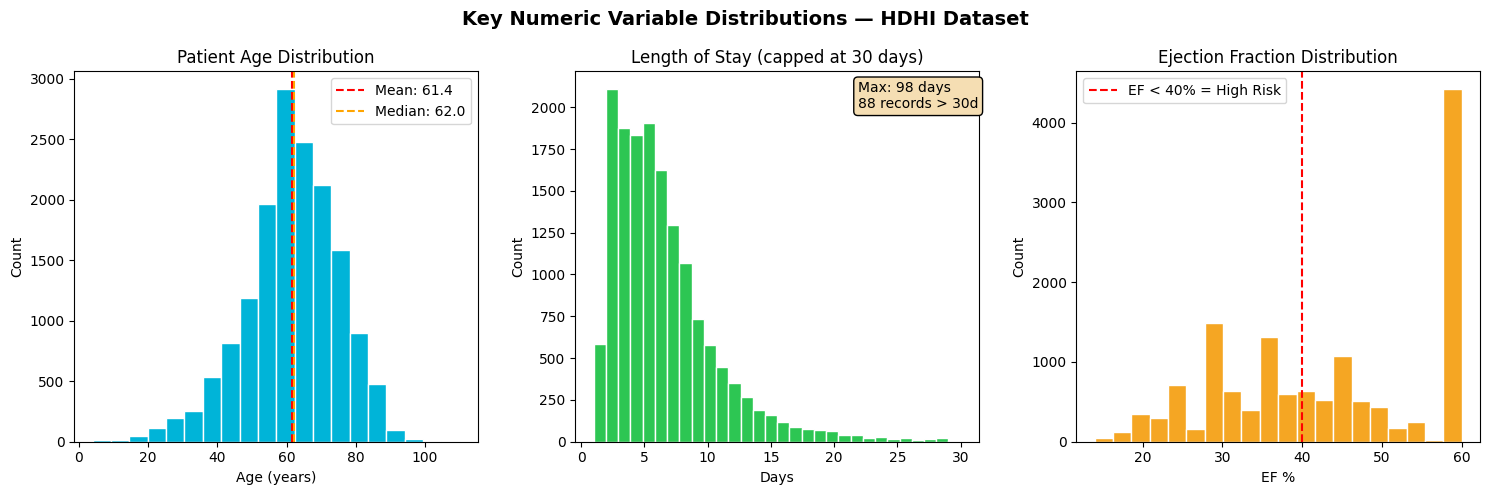

Chart saved: eda_03_numeric_distributions.png


In [6]:
# Key numeric columns
numerics = {
    'AGE': {'min_expected': 0, 'max_expected': 110,
            'flag_low': 15, 'flag_high': 100},
    'DURATION OF STAY': {'min_expected': 1, 'max_expected': 200,
                         'flag_low': None, 'flag_high': 60},
    'EF': {'min_expected': 0, 'max_expected': 100,
           'flag_low': 5, 'flag_high': 85},
    'CREATININE': {'min_expected': 0, 'max_expected': 50,
                   'flag_low': None, 'flag_high': 15},
    'GLUCOSE': {'min_expected': 0, 'max_expected': 2000,
                'flag_low': None, 'flag_high': 1000},
    'HB': {'min_expected': 0, 'max_expected': 25,
           'flag_low': 2, 'flag_high': 20}
}

# Coerce to numeric for analysis (raw has 'EMPTY' strings in lab columns)
for col in numerics:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric Column Summary:")
print(f"{'Column':<25} {'Min':>8} {'Max':>8} {'Mean':>8} {'Median':>8} {'Nulls':>8}")
print("-" * 70)

for col, thresholds in numerics.items():
    if col in df.columns:
        series = df[col].dropna()
        print(f"{col:<25} {series.min():>8.1f} {series.max():>8.1f} "
              f"{series.mean():>8.1f} {series.median():>8.1f} "
              f"{df[col].isnull().sum():>8}")

# Flag outliers
print("\n⚠️  Outlier Flags:")
for col, thresholds in numerics.items():
    if col in df.columns:
        if thresholds['flag_low']:
            low_count = (df[col] < thresholds['flag_low']).sum()
            if low_count > 0:
                print(f"  {col} < {thresholds['flag_low']}: "
                      f"{low_count} records")
        if thresholds['flag_high']:
            high_count = (df[col] > thresholds['flag_high']).sum()
            if high_count > 0:
                print(f"  {col} > {thresholds['flag_high']}: "
                      f"{high_count} records")
                examples = df[df[col] > thresholds['flag_high']][col].head(3).tolist()
                print(f"    Example values: {examples}")

# Age distribution chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['AGE'].dropna(), bins=20,
             color='#00B4D8', edgecolor='white')
axes[0].axvline(df['AGE'].mean(), color='red',
                linestyle='--', label=f"Mean: {df['AGE'].mean():.1f}")
axes[0].axvline(df['AGE'].median(), color='orange',
                linestyle='--', label=f"Median: {df['AGE'].median():.1f}")
axes[0].set_title('Patient Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

los = df['DURATION OF STAY'].dropna()
los_capped = los[los <= 30]
axes[1].hist(los_capped, bins=30,
             color='#2DC653', edgecolor='white')
axes[1].set_title('Length of Stay (capped at 30 days)')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Count')
axes[1].text(0.7, 0.9,
             f"Max: {los.max():.0f} days\n{(los > 30).sum()} records > 30d",
             transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat'))

ef = df['EF'].dropna()
axes[2].hist(ef, bins=20, color='#F5A623', edgecolor='white')
axes[2].axvline(40, color='red', linestyle='--', label='EF < 40% = High Risk')
axes[2].set_title('Ejection Fraction Distribution')
axes[2].set_xlabel('EF %')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Key Numeric Variable Distributions — HDHI Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/screenshots/eda_03_numeric_distributions.png', dpi=150)
plt.show()
print("Chart saved: eda_03_numeric_distributions.png")

## 8. Date Validation
Checking for impossible dates and format inconsistencies.
Indian hospitals often use DD/MM/YYYY format which pandas
can misinterpret as MM/DD/YYYY without explicit handling.

In [7]:
# Sample raw date values
print("Sample D.O.A values (raw):")
print(df['D.O.A'].head(10).tolist())

print("\nSample D.O.D values (raw):")
print(df['D.O.D'].head(10).tolist())

# Try parsing with dayfirst=True (Indian convention)
try:
    doa = pd.to_datetime(df['D.O.A'], dayfirst=True, errors='coerce')
    dod = pd.to_datetime(df['D.O.D'], dayfirst=True, errors='coerce')

    print(f"\nD.O.A parse failures: {doa.isnull().sum()}")
    print(f"D.O.D parse failures: {dod.isnull().sum()}")
    print(f"D.O.A range: {doa.min().date()} to {doa.max().date()}")
    print(f"D.O.D range: {dod.min().date()} to {dod.max().date()}")

    impossible = (dod < doa).sum()
    print(f"\nImpossible dates (D.O.D before D.O.A): {impossible}")

    calculated_los = (dod - doa).dt.days
    mismatch = (calculated_los != df['DURATION OF STAY']).sum()
    print(f"LOS mismatch (calculated vs reported): {mismatch}")

except Exception as e:
    print(f"Date parsing error: {e}")

Sample D.O.A values (raw):
['4/1/2017', '4/1/2017', '4/1/2017', '4/1/2017', '4/1/2017', '4/1/2017', '4/1/2017', '4/1/2017', '4/1/2017', '4/1/2017']

Sample D.O.D values (raw):
['4/3/2017', '4/5/2017', '4/3/2017', '4/8/2017', '4/23/2017', '4/10/2017', '4/6/2017', '4/13/2017', '4/3/2017', '4/3/2017']

D.O.A parse failures: 3767
D.O.D parse failures: 3770
D.O.A range: 2017-01-04 to 2019-12-03
D.O.D range: 2017-01-05 to 2019-12-03

Impossible dates (D.O.D before D.O.A): 13
LOS mismatch (calculated vs reported): 15734


## 9. BNP Missing Value Deep Dive
BNP (Brain Natriuretic Peptide) is a key cardiac stress marker.
With 53.6% missing, this is the most significant data quality issue.
We need to understand WHY it is missing before deciding how to handle it.

In [8]:
# BNP missing vs present by outcome
print("BNP presence by patient outcome:")
df['bnp_present'] = df['BNP'].notna()
bnp_outcome = df.groupby('OUTCOME')['bnp_present'].agg(['sum', 'count'])
bnp_outcome['pct_present'] = (bnp_outcome['sum'] /
                               bnp_outcome['count'] * 100).round(1)
print(bnp_outcome)

print("\nBNP presence by admission type:")
bnp_type = df.groupby(
    'TYPE OF ADMISSION-EMERGENCY/OPD')['bnp_present'].agg(['sum', 'count'])
bnp_type['pct_present'] = (bnp_type['sum'] /
                            bnp_type['count'] * 100).round(1)
print(bnp_type)

bnp_values = pd.to_numeric(df['BNP'], errors='coerce').dropna()
print(f"\nBNP statistics where measured:")
print(f"  Count:  {len(bnp_values):,}")
print(f"  Min:    {bnp_values.min():.1f}")
print(f"  Max:    {bnp_values.max():.1f}")
print(f"  Mean:   {bnp_values.mean():.1f}")
print(f"  Median: {bnp_values.median():.1f}")
print(f"\nDecision: Fill with median ({bnp_values.median():.1f})")
print("Reason: Cannot drop 8,441 rows. Mean is skewed by extreme values.")
print("Limitation: BNP should NOT be used in correlation analysis.")

BNP presence by patient outcome:
            sum  count  pct_present
OUTCOME                            
DAMA        505    896         56.4
DISCHARGE  6175  13756         44.9
EXPIRY      636   1105         57.6

BNP presence by admission type:
                                  sum  count  pct_present
TYPE OF ADMISSION-EMERGENCY/OPD                          
E                                5707  10924         52.2
O                                1609   4833         33.3

BNP statistics where measured:
  Count:  6,676
  Min:    4.0
  Max:    5000.0
  Mean:   817.8
  Median: 470.5

Decision: Fill with median (470.5)
Reason: Cannot drop 8,441 rows. Mean is skewed by extreme values.
Limitation: BNP should NOT be used in correlation analysis.


## 10. Key Findings from EDA

### Finding 1 — Outcome Imbalance
87.3% discharged, 7.01% expired, 5.69% DAMA.
This means 12.7% of all admissions had unfavourable outcomes.

### Finding 2 — The BNP Problem
53.6% of BNP values are missing (8,441 of 15,757 records).
BNP is a critical cardiac stress marker but cannot be used
as a reliable predictor due to this missingness rate.
Decision: fill with median for risk scoring only.
Excluded from any correlation or regression analysis.

### Finding 3 — Repeat Admissions
3,513 admissions are repeat visits from existing patients.
12,244 unique patients generated 15,757 admissions.
Each admission is a valid clinical event — keep all rows.
Do not deduplicate by MRD No.

### Finding 4 — Age Outliers
Ages under 15 and over 100 exist in the dataset.
Decision: keep all records — extreme ages are clinically possible
in a cardiac unit. Flag in analysis but do not remove.

### Finding 5 — Length of Stay Outliers
LOS up to 98 days exists.
Decision: keep all records. Cap chart display at 30 days
for readability but use full data in calculations.

### Finding 6 — Emergency Dominance
69.3% of admissions came through emergency.
This is a tertiary cardiac unit that primarily handles
acute cases rather than planned procedures.
This context is important for interpreting all findings.

### Finding 7 — Comorbidity Burden
Nearly half of all patients have hypertension.
One third have diabetes.
These are not outliers — they reflect India's chronic
disease epidemic in cardiac populations.

## 11. Data Cleaning Decisions — Preview
Full decisions documented in docs/DATA_CLEANING_DECISIONS.md

| Issue | Decision | Reason |
|-------|----------|--------|
| BNP 53.6% missing | Fill with median | Too many rows to drop |
| EF 9.5% missing | Fill with median | Clinically important |
| Age < 15 or > 100 | Keep, flag | May be valid edge cases |
| LOS > 60 days | Keep, cap chart at 30 | Genuine long admissions |
| Date format D.O.A | Parse dayfirst=True | Indian DD/MM/YYYY convention |
| RURAL R/U | Map to Rural/Urban | Readability |
| OUTCOME codes | Map to full words | Standardise |
| Repeat admissions | Keep all rows | Each admission is valid |
| Column names | Rename to snake_case | Professional convention |